In [5]:
!pip install -q -U keras-tuner


In [6]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
from sklearn.model_selection import KFold
from matplotlib import pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve
import numpy as np
import keras_tuner as kt  # Keras Tuner

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Set global seeds for reproducibility
seed = 712
tf.random.set_seed(seed)
np.random.seed(seed)

In [8]:
data_dir = '/content/drive/My Drive/breakhis'  # Replace with your actual path to the dataset


In [9]:
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class PAM(layers.Layer):
    """Position Attention Module"""
    def __init__(self, **kwargs):
        super(PAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.query_conv = layers.Conv2D(input_shape[-1] // 8, kernel_size=1)
        self.key_conv = layers.Conv2D(input_shape[-1] // 8, kernel_size=1)
        self.value_conv = layers.Conv2D(input_shape[-1], kernel_size=1)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = self.query_conv(inputs)  # [batch, h, w, c//8]
        key = self.key_conv(inputs)  # [batch, h, w, c//8]
        value = self.value_conv(inputs)  # [batch, h, w, c]

        # Compute attention
        query = tf.reshape(query, [tf.shape(query)[0], -1, tf.shape(query)[-1]])  # [batch, hw, c//8]
        key = tf.transpose(tf.reshape(key, [tf.shape(key)[0], -1, tf.shape(key)[-1]]), perm=[0, 2, 1])  # [batch, c//8, hw]
        energy = tf.matmul(query, key)  # [batch, hw, hw]
        attention = tf.nn.softmax(energy, axis=-1)  # Spatial attention

        value = tf.reshape(value, [tf.shape(value)[0], -1, tf.shape(value)[-1]])  # [batch, hw, c]
        out = tf.matmul(attention, value)  # [batch, hw, c]
        out = tf.reshape(out, tf.shape(inputs))  # Restore shape
        return self.gamma * out + inputs

    def get_config(self):
        config = super(PAM, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


@register_keras_serializable()
class CAM(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, **kwargs):
        super(CAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        # Compute attention
        query = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])  # [batch, hw, c]
        key = tf.transpose(query, perm=[0, 2, 1])  # [batch, c, hw]
        energy = tf.matmul(key, query)  # [batch, c, c]
        attention = tf.nn.softmax(energy, axis=-1)  # Channel attention

        value = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])  # [batch, hw, c]
        out = tf.matmul(value, attention)  # [batch, hw, c]
        out = tf.reshape(out, tf.shape(inputs))  # Restore shape
        return self.gamma * out + inputs

    def get_config(self):
        config = super(CAM, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


@register_keras_serializable()
class DANetBlock(layers.Layer):
    """Dual Attention Network Block"""
    def __init__(self, **kwargs):
        super(DANetBlock, self).__init__(**kwargs)
        self.pam = PAM()
        self.cam = CAM()

    def call(self, inputs):
        pam_out = self.pam(inputs)
        cam_out = self.cam(inputs)
        return pam_out + cam_out  # Combine PAM and CAM outputs

    def get_config(self):
        config = super(DANetBlock, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [11]:
def build_model(input_shape=(256,256,3), lr=4e-4):
    inp = tf.keras.Input(shape=input_shape)

    # Conv blocks (unchanged aside from naming)
    x = layers.Conv2D(64,3,padding='same',activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    # **CHANGED**: name this layer so Grad‑CAM can hook it
    x = layers.Conv2D(256,3,padding='same',activation='relu', name='last_conv')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = DANetBlock()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,activation='relu',kernel_regularizer='l2')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128,activation='relu',kernel_regularizer='l2')(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1,activation='sigmoid')(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [12]:
# Test DANetBlock
x_test = tf.random.normal((1, 64, 64, 256))  # Example input
danet_block = DANetBlock()
x_out = danet_block(x_test)

print(f"Output shape: {x_out.shape}")


Output shape: (1, 64, 64, 256)


In [13]:

# Step 3: Load and prepare datasets with a given batch size
img_size = (256, 256)


def prepare_datasets(batch_size):
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )

    val_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )

    # Data Augmentation and Normalization
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.Lambda(lambda x: tf.image.random_brightness(x, max_delta=0.3)),
        tf.keras.layers.Lambda(lambda x: tf.image.random_saturation(x, lower=0.8, upper=1.2)),
    ])

    normalization_layer = tf.keras.layers.Rescaling(1./255)
    train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x), training=True), y))
    val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

    return train_dataset, val_dataset

In [ ]:

# Train and evaluate the model
batch_size = 16
train_dataset, val_dataset = prepare_datasets(batch_size=batch_size)

Found 7670 files belonging to 2 classes.
Using 6136 files for training.
Found 7670 files belonging to 2 classes.
Using 1534 files for validation.


In [14]:
from tensorflow.keras.callbacks import EarlyStopping
# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=8,          # Number of epochs with no improvement after which training will stop
    restore_best_weights=True)  # Restore the best weights when training stops


In [ ]:
model = build_model()
history = model.fit(train_dataset, validation_data=val_dataset, epochs=50,callbacks=[early_stopping])



Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 846s 2s/step - accuracy: 0.7791 - loss: 4.1325 - val_accuracy: 0.7275 - val_loss: 3.7370
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 131s 340ms/step - accuracy: 0.8472 - loss: 2.1822 - val_accuracy: 0.8657 - val_loss: 1.3834
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 130s 338ms/step - accuracy: 0.8511 - loss: 1.2462 - val_accuracy: 0.7419 - val_loss: 1.1043
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 131s 341ms/step - accuracy: 0.8630 - loss: 0.7510 - val_accuracy: 0.6825 - val_loss: 0.9486
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 129s 335ms/step - accuracy: 0.8656 - loss: 0.5284 - val_accuracy: 0.4022 - val_loss: 1.0906
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 131s 341ms/step - accuracy: 0.8684 - loss: 0.4170 - val_accuracy: 0.8468 - val_loss: 0.4514
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 126s 327ms/step - accuracy: 0.8808 - loss: 0.3636 - val_accuracy: 0.8227 - val_loss: 0.4552
Epoch 8/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 129s 334ms/step - accuracy: 0.8844 - lo

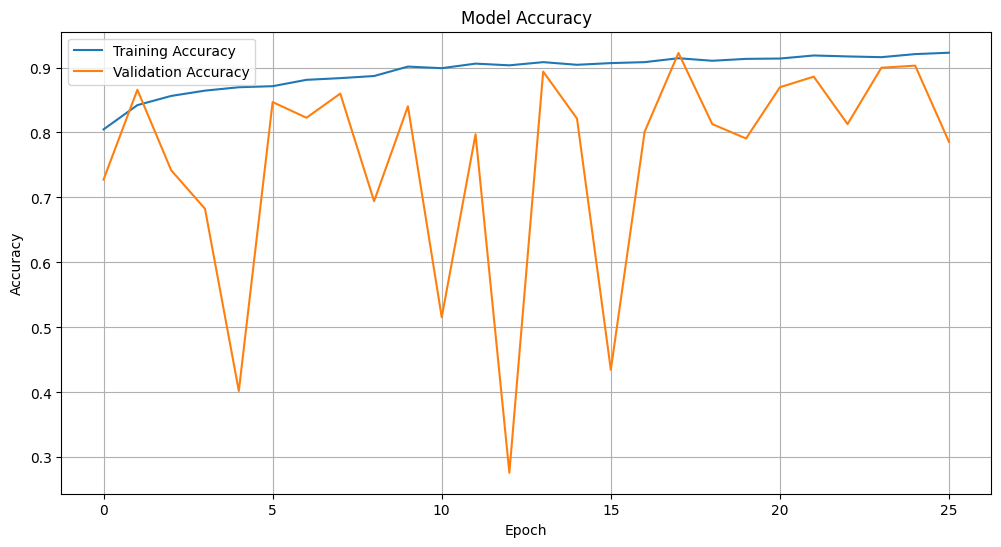

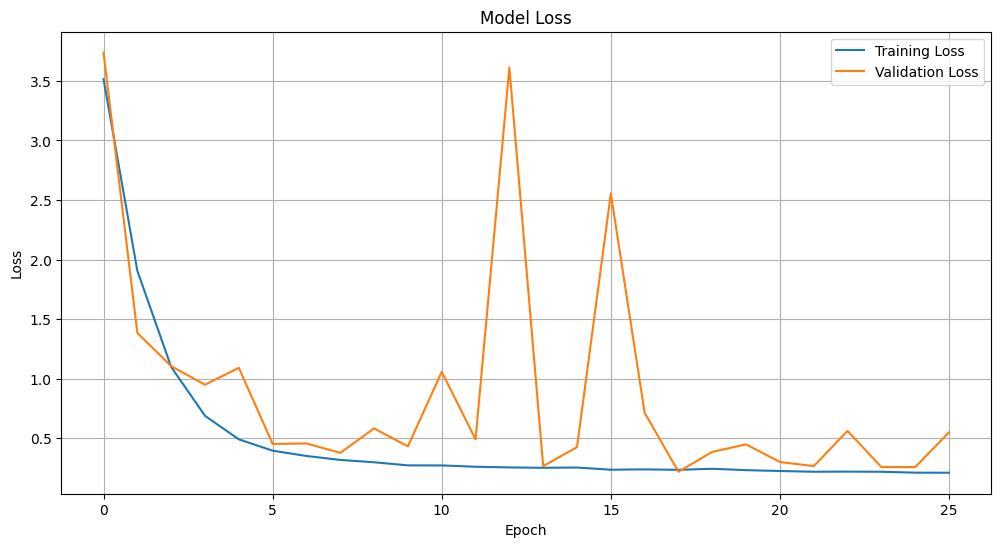

In [ ]:
# Plot Loss and Accuracy During Training
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Evaluate the model on validation dataset
y_true = []
y_pred_probs = []

for batch in val_dataset.as_numpy_iterator():
    X, y = batch
    preds = model.predict(X)
    y_true.extend(y)
    y_pred_probs.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━

In [ ]:
# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

In [ ]:
# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_probs)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

Accuracy: 0.9224
Precision: 0.9407
Recall: 0.9534
F1 Score: 0.9470
AUC-ROC: 0.9715


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


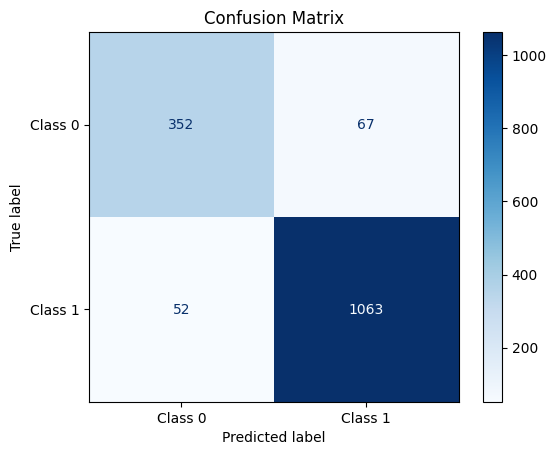

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

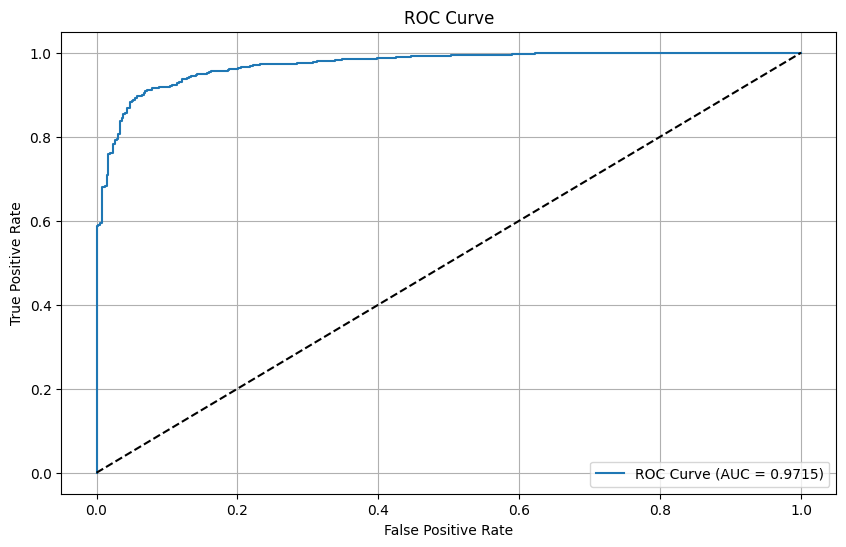

In [ ]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

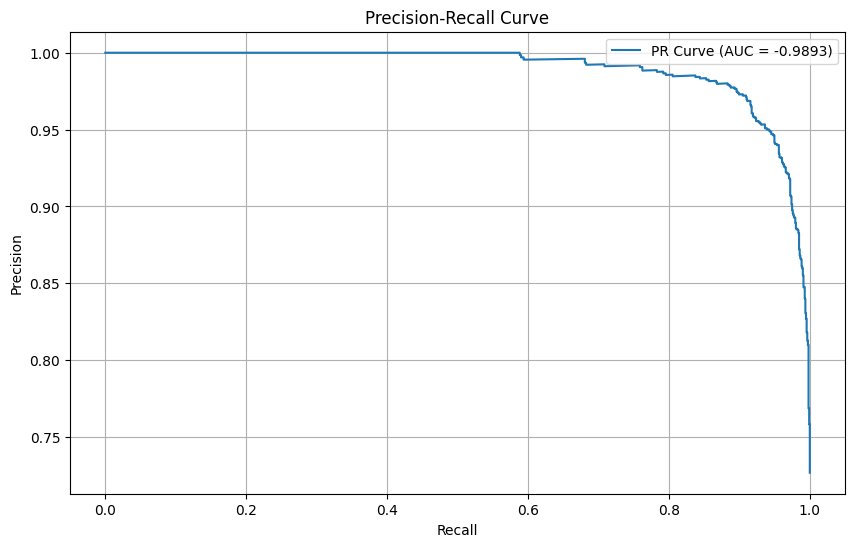

In [ ]:
from sklearn.metrics import precision_recall_curve

# Plot PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = np.trapz(precision_vals, recall_vals)
plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [5]:
import os

In [ ]:
# Save the trained model
directory_path = '/content/drive/My Drive/saved_model'
model_path = os.path.join(directory_path, 'cnn_model_breast_danet_main9.keras')
os.makedirs(directory_path, exist_ok=True)
model.save(model_path)
print(f"Model saved at: {model_path}")

Model saved at: /content/drive/My Drive/saved_model/cnn_model_breast_danet_main9.keras


In [6]:
directory_path = '/content/drive/My Drive/saved_model'
model_path = os.path.join(directory_path, 'cnn_model_breast_danet_main9.keras')


In [15]:
from tensorflow.keras.models import load_model

# Register custom layers
custom_objects = {
    'PAM': PAM,
    'CAM': CAM,
    'DANetBlock': DANetBlock
}

# Load the model with custom objects
model = load_model(model_path, custom_objects=custom_objects)

ValueError: The `{arg_name}` of this `Lambda` layer is a Python lambda. Deserializing it is unsafe. If you trust the source of the config artifact, you can override this error by passing `safe_mode=False` to `from_config()`, or calling `keras.config.enable_unsafe_deserialization().

In [ ]:

def test_single_class_dataset(dataset_dir, batch_size=1, threshold=0.5):
    # Load the single-class dataset
    dataset = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        image_size=(256, 256),
        batch_size=batch_size,
        label_mode='int',
        shuffle=False
    )

    # Normalize the dataset
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    # Evaluate the model
    y_true = []
    y_pred_probs = []

    for X, y in normalized_dataset:
        preds = model.predict(X)
        y_true.extend(y.numpy())
        y_pred_probs.extend(preds.flatten())

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > threshold).astype(int)

    # Compute metrics
    accuracy = tf.keras.metrics.Accuracy()(y_true, y_pred).numpy()
    precision = tf.keras.metrics.Precision()(y_true, y_pred).numpy()
    recall = tf.keras.metrics.Recall()(y_true, y_pred).numpy()
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix
    confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(confusion_mtx.numpy())

# Test the model
single_class_dataset_dir = '/content/drive/My Drive/mal'  # Replace with your path
test_single_class_dataset(single_class_dataset_dir, batch_size=16, threshold=0.5)

Found 122 files belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: nan


<ipython-input-24-f71f4c488ec2>:33: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (precision * recall) / (precision + recall)


Confusion Matrix:
[[122]]


In [ ]:
import tensorflow as tf
import numpy as np

def test_single_class_dataset(dataset_dir, batch_size=16, threshold=0.5):
    # Load the single-class dataset
    try:
        dataset = tf.keras.utils.image_dataset_from_directory(
            dataset_dir,
            image_size=(256, 256),
            batch_size=batch_size,
            label_mode='int',
            shuffle=False
        )
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    # Normalize the dataset
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    # Evaluate the model
    y_true = []
    y_pred_probs = []

    for X, y in normalized_dataset:
        preds = model.predict(X)
        y_true.extend(y.numpy())
        y_pred_probs.extend(preds.flatten())

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > threshold).astype(int)

    # Compute metrics
    accuracy = tf.keras.metrics.Accuracy()(y_true, y_pred).numpy()
    total_samples = len(y_true)
    true_predictions = np.sum(y_true == y_pred)

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Total number of samples: {total_samples}")
    print(f"Number of true predictions: {true_predictions}")



# Test the model
single_class_dataset_dir = '/content/drive/My Drive/mal'  # Replace with your path
test_single_class_dataset(single_class_dataset_dir, batch_size=16, threshold=0.5)

Found 122 files belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Accuracy: 1.0000
Total number of samples: 122
Number of true predictions: 122


In [ ]:
import tensorflow as tf
import numpy as np

def test_single_class_dataset(dataset_dir, batch_size=16, threshold=0.5):
    # Load the single-class dataset
    try:
        dataset = tf.keras.utils.image_dataset_from_directory(
            dataset_dir,
            image_size=(256, 256),
            batch_size=batch_size,
            label_mode='int',
            shuffle=False
        )
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    # Normalize the dataset
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    # Evaluate the model
    y_true = []
    y_pred_probs = []

    for X, y in normalized_dataset:
        preds = model.predict(X)
        y_true.extend(y.numpy())
        y_pred_probs.extend(preds.flatten())

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs < threshold).astype(int)

    # Compute metrics
    accuracy = tf.keras.metrics.Accuracy()(y_true, y_pred).numpy()
    total_samples = len(y_true)
    true_predictions = np.sum(y_true == y_pred)

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Total number of samples: {total_samples}")
    print(f"Number of true predictions: {true_predictions}")



# Test the model
single_class_dataset_dir = '/content/drive/My Drive/beenn'  # Replace with your path
test_single_class_dataset(single_class_dataset_dir, batch_size=16, threshold=0.5)

Found 32 files belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Accuracy: 0.8125
Total number of samples: 32
Number of true predictions: 26


In [11]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.models import load_model

# --- Register custom layers ---
from tensorflow.keras import layers
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class PAM(layers.Layer):
    def __init__(self, **kwargs):
        super(PAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.query_conv = layers.Conv2D(input_shape[-1] // 8, 1)
        self.key_conv = layers.Conv2D(input_shape[-1] // 8, 1)
        self.value_conv = layers.Conv2D(input_shape[-1], 1)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = self.query_conv(inputs)
        key = self.key_conv(inputs)
        value = self.value_conv(inputs)

        query = tf.reshape(query, [tf.shape(query)[0], -1, tf.shape(query)[-1]])
        key = tf.transpose(tf.reshape(key, [tf.shape(key)[0], -1, tf.shape(key)[-1]]), perm=[0, 2, 1])
        energy = tf.matmul(query, key)
        attention = tf.nn.softmax(energy, axis=-1)

        value = tf.reshape(value, [tf.shape(value)[0], -1, tf.shape(value)[-1]])
        out = tf.matmul(attention, value)
        out = tf.reshape(out, tf.shape(inputs))
        return self.gamma * out + inputs

@register_keras_serializable()
class CAM(layers.Layer):
    def __init__(self, **kwargs):
        super(CAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])
        key = tf.transpose(query, perm=[0, 2, 1])
        energy = tf.matmul(key, query)
        attention = tf.nn.softmax(energy, axis=-1)

        value = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])
        out = tf.matmul(value, attention)
        out = tf.reshape(out, tf.shape(inputs))
        return self.gamma * out + inputs

@register_keras_serializable()
class DANetBlock(layers.Layer):
    def __init__(self, **kwargs):
        super(DANetBlock, self).__init__(**kwargs)
        self.pam = PAM()
        self.cam = CAM()

    def call(self, inputs):
        pam_out = self.pam(inputs)
        cam_out = self.cam(inputs)
        return pam_out + cam_out

# --- Load Model ---
model_path = '/content/drive/My Drive/saved_model/cnn_model_breast_danet_main17.keras'
model = load_model(
    model_path,
    custom_objects={
        'PAM': PAM,
        'CAM': CAM,
        'DANetBlock': DANetBlock
    },
    safe_mode=False  # This fixes the issue
)

# --- Rest of your code remains the same ---
# --- Function to test single-class dataset ---
def test_single_class_dataset(dataset_dir, batch_size=16, threshold=0.5):
    try:
        dataset = tf.keras.utils.image_dataset_from_directory(
            dataset_dir,
            image_size=(256, 256),
            batch_size=batch_size,
            label_mode='int',
            shuffle=False
        )
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    y_true, y_pred_probs = [], []

    for X, y in normalized_dataset:
        preds = model.predict(X, verbose=0)
        y_true.extend(y.numpy())
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > threshold).astype(int)

    accuracy = np.mean(y_true == y_pred)
    total = len(y_true)
    correct = np.sum(y_true == y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Total Samples: {total}")
    print(f"Correct Predictions: {correct}")

# --- Test path ---
test_path = '/content/drive/My Drive/mal'  # Your single-class dataset path
test_single_class_dataset(test_path, batch_size=16, threshold=0.5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'danet_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Found 122 files belonging to 1 classes.
Accuracy: 0.9590
Total Samples: 122
Correct Predictions: 117


In [12]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.models import load_model

# --- Register custom layers ---
from tensorflow.keras import layers
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class PAM(layers.Layer):
    def __init__(self, **kwargs):
        super(PAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.query_conv = layers.Conv2D(input_shape[-1] // 8, 1)
        self.key_conv = layers.Conv2D(input_shape[-1] // 8, 1)
        self.value_conv = layers.Conv2D(input_shape[-1], 1)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = self.query_conv(inputs)
        key = self.key_conv(inputs)
        value = self.value_conv(inputs)

        query = tf.reshape(query, [tf.shape(query)[0], -1, tf.shape(query)[-1]])
        key = tf.transpose(tf.reshape(key, [tf.shape(key)[0], -1, tf.shape(key)[-1]]), perm=[0, 2, 1])
        energy = tf.matmul(query, key)
        attention = tf.nn.softmax(energy, axis=-1)

        value = tf.reshape(value, [tf.shape(value)[0], -1, tf.shape(value)[-1]])
        out = tf.matmul(attention, value)
        out = tf.reshape(out, tf.shape(inputs))
        return self.gamma * out + inputs

@register_keras_serializable()
class CAM(layers.Layer):
    def __init__(self, **kwargs):
        super(CAM, self).__init__(**kwargs)

    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])
        key = tf.transpose(query, perm=[0, 2, 1])
        energy = tf.matmul(key, query)
        attention = tf.nn.softmax(energy, axis=-1)

        value = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])
        out = tf.matmul(value, attention)
        out = tf.reshape(out, tf.shape(inputs))
        return self.gamma * out + inputs

@register_keras_serializable()
class DANetBlock(layers.Layer):
    def __init__(self, **kwargs):
        super(DANetBlock, self).__init__(**kwargs)
        self.pam = PAM()
        self.cam = CAM()

    def call(self, inputs):
        pam_out = self.pam(inputs)
        cam_out = self.cam(inputs)
        return pam_out + cam_out

# --- Load Model ---
model_path = '/content/drive/My Drive/saved_model/cnn_model_breast_danet_main17.keras'
model = load_model(
    model_path,
    custom_objects={
        'PAM': PAM,
        'CAM': CAM,
        'DANetBlock': DANetBlock
    },
    safe_mode=False  # This fixes the issue
)

# --- Rest of your code remains the same ---
# --- Function to test single-class dataset ---
def test_single_class_dataset(dataset_dir, batch_size=16, threshold=0.5):
    try:
        dataset = tf.keras.utils.image_dataset_from_directory(
            dataset_dir,
            image_size=(256, 256),
            batch_size=batch_size,
            label_mode='int',
            shuffle=False
        )
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    y_true, y_pred_probs = [], []

    for X, y in normalized_dataset:
        preds = model.predict(X, verbose=0)
        y_true.extend(y.numpy())
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs < threshold).astype(int)

    accuracy = np.mean(y_true == y_pred)
    total = len(y_true)
    correct = np.sum(y_true == y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Total Samples: {total}")
    print(f"Correct Predictions: {correct}")

# --- Test path ---
test_path = '/content/drive/My Drive/beenn'  # Your single-class dataset path
test_single_class_dataset(test_path, batch_size=16, threshold=0.5)

Found 32 files belonging to 1 classes.
Accuracy: 1.0000
Total Samples: 32
Correct Predictions: 32
